           X1        X2        X5
0   -0.155036  1.390534 -1.641349
1   -0.061638 -1.031482 -1.429991
2   -1.306522 -1.093895  0.205797
3    1.117016  0.944479 -0.912822
4   -0.864045 -0.306766 -0.406303
..        ...       ...       ...
495 -0.179925  1.895889  1.178780
496  0.191451  0.536597  0.404695
497  1.047972  0.175819  0.498690
498  0.442846  0.156476 -0.216344
499  0.419524 -0.036597 -0.084223

[500 rows x 3 columns]


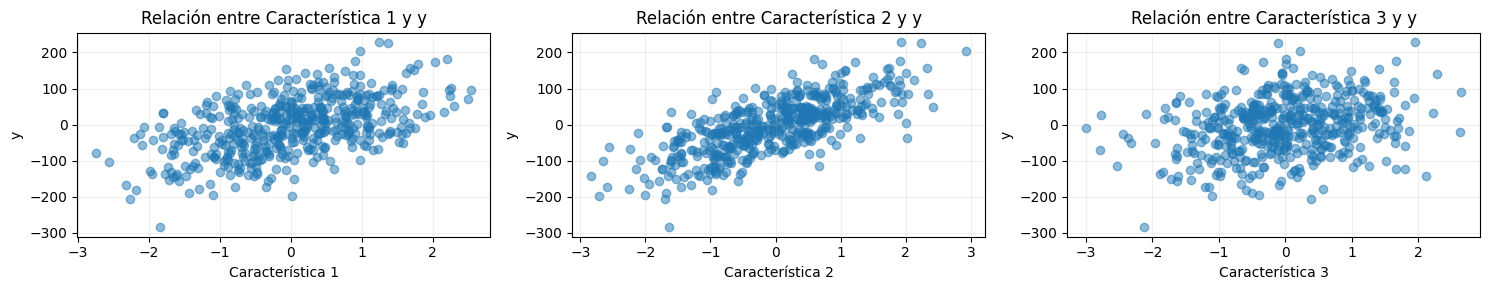

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import math
import pandas as pd

n = 500
features = 5
X, y = make_regression(
    n_samples=n,
    n_features=features,
    noise=math.sqrt(n),
    random_state=0,
    n_informative=3,
)

X = pd.DataFrame(X, columns=[f"X{x + 1}" for x in range(0, 5)]).iloc[:, [0, 1, 4]]
print(X)
fig, axes = plt.subplots(1, X.shape[1], figsize=(15, 3))
for i in range(X.shape[1]):
    axes[i].scatter(X.iloc[:, i], y, alpha=0.5)
    axes[i].set_xlabel(f"Característica {i+1}")
    axes[i].set_ylabel("y")
    axes[i].set_title(f"Relación entre Característica {i+1} y y")
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, test_size=0.3)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)
reg.coef_

array([42.70854282, 56.61293472, 27.8514313 ])

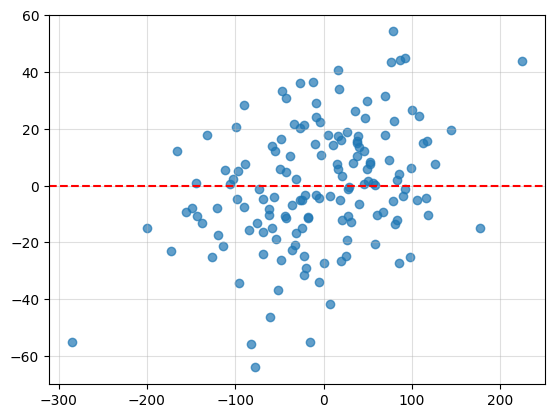

In [3]:
import matplotlib.pyplot as plt

res = y_test - y_pred

plt.scatter(y_test, res, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.grid(True, alpha=0.4)
plt.show()

In [5]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R^2", r2)
print("MSE", mse)
print("RMSE", rmse)
print("MAE", mae)


var = [f"X{i+1}" for i in range(X.shape[1])]
coef = pd.DataFrame(reg.coef_)
coef.sort_values(by=0, key=abs)

R^2 0.9260242585429269
MSE 467.7435564872211
RMSE 21.627379787834244
MAE 17.084179915081847


,0
2,27.851431
0,42.708543
1,56.612935
